In [ ]:
!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms yfinance xgboost seaborn pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=0ac190603cfdf04c78aa7459b0b9425ff2afe851f29966ce47d8bce90fb5cb3a
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from qiskit.visualization import circuit_drawer
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliFeatureMap
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA, OptimizerResult

In [ ]:
%matplotlib inline

In [ ]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

data["Return"] = data["Close"].pct_change()
data["MA5"] = data["Close"].rolling(5).mean()
data["MA10"] = data["Close"].rolling(10).mean()
data["Volatility"] = data["Return"].rolling(5).std()
data["Target"] = (data["Return"].shift(-1) > 0).astype(int)

data = data.dropna()

/tmp/ipykernel_5186/3316706990.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


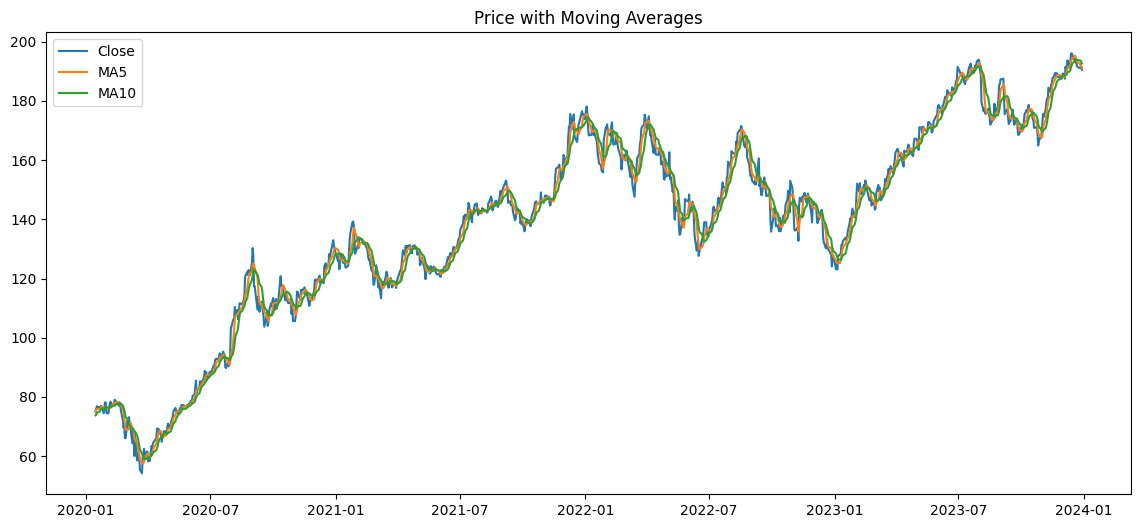

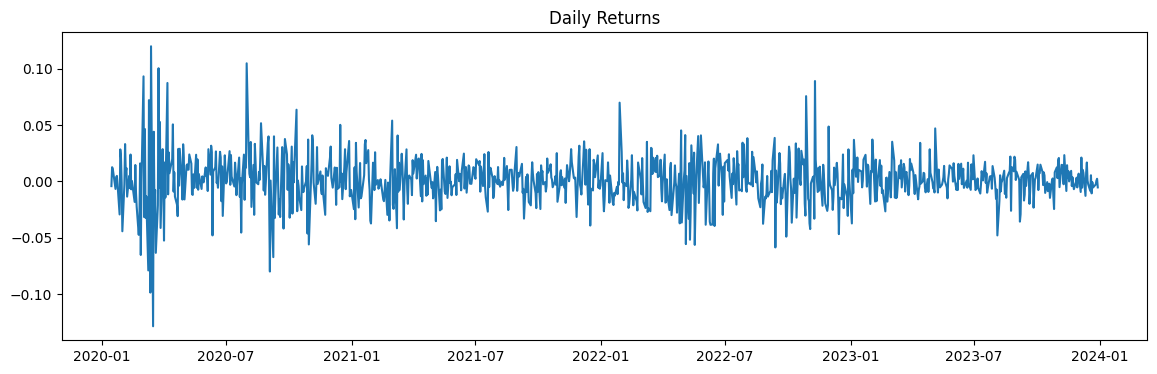

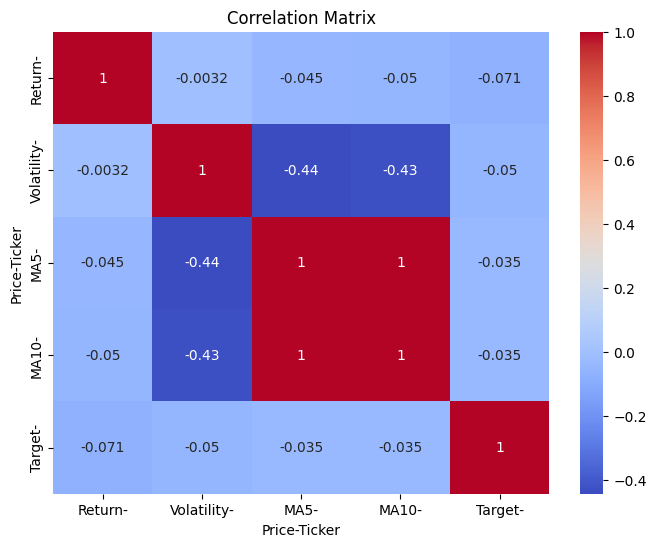

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA5"], label="MA5")
plt.plot(data.index, data["MA10"], label="MA10")
plt.title("Price with Moving Averages")
plt.legend()
plt.show()

print()

plt.figure(figsize=(14,4))
plt.plot(data.index, data["Return"])
plt.title("Daily Returns")
plt.show()

print()

plt.figure(figsize=(8,6))
sns.heatmap(data[["Return","Volatility","MA5","MA10","Target"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
features = ["Return","Volatility","MA5","MA10"]
X = data[features].values
y = data["Target"].values

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LogReg
Train: 0.5458
Test: 0.43
ROC: 0.4843

RandomForest
Train: 0.7378
Test: 0.51
ROC: 0.554

XGBoost
Train: 1.0
Test: 0.555
ROC: 0.5882



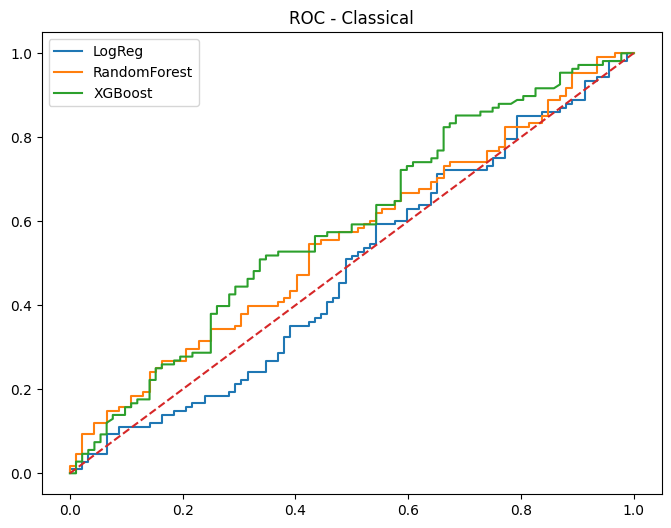

In [ ]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6),
    "XGBoost": XGBClassifier()
}

results = []

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    probs = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    results.append([name, train_acc, test_acc, roc, "Classical", "-"])

    print(name)
    print("Train:", round(train_acc,4))
    print("Test:", round(test_acc,4))
    print("ROC:", round(roc,4))
    print()

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC - Classical")
plt.legend()
plt.show()

In [ ]:
class CallbackOptimizer(COBYLA):
    def __init__(self, maxiter=100):
        super().__init__(maxiter=maxiter)
        self.history = []

    def minimize(self, fun, x0, jac=None, bounds=None):
        self.history = []

        def wrapped_fun(x):
            value = fun(x)
            self.history.append(value)
            print(f"Loss: {value:.4f}")
            return value

        result = super().minimize(wrapped_fun, x0, jac, bounds)
        result.history = self.history
        return result

def train_vqc(feature_map, ansatz, label, maxiter=100):

    optimizer = CallbackOptimizer(maxiter=maxiter)

    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer
    )

    start = time.time()
    vqc.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = accuracy_score(y_train, vqc.predict(X_train))
    test_acc = accuracy_score(y_test, vqc.predict(X_test))
    probs = vqc.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    print(f"{label} ROC: {roc:.4f} | Time: {train_time:.1f}s")

    return vqc, optimizer.history, train_acc, test_acc, roc, train_time

In [ ]:
configs = {
    "ZZ_r1_RA_r2": (ZZFeatureMap(4, reps=1), RealAmplitudes(4, reps=2)),
    "ZZ_r2_RA_r2": (ZZFeatureMap(4, reps=2), RealAmplitudes(4, reps=2)),
    "ZZ_r2_RA_r3": (ZZFeatureMap(4, reps=2), RealAmplitudes(4, reps=3)),
    "Pauli_r1_RA_r2": (PauliFeatureMap(4, reps=1), RealAmplitudes(4, reps=2))
}

/tmp/ipykernel_5186/271364915.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  "ZZ_r1_RA_r2": (ZZFeatureMap(4, reps=1), RealAmplitudes(4, reps=2)),
/tmp/ipykernel_5186/271364915.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  "ZZ_r1_RA_r2": (ZZFeatureMap(4, reps=1), RealAmplitudes(4, reps=2)),
/tmp/ipykernel_5186/271364915.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacem

In [ ]:
vqc_models = {}
loss_histories = {}
roc_scores = {}
train_times = {}

for name, (fmap, ansatz) in configs.items():

    print("\nTraining:", name)

    model, losses, train_acc, test_acc, roc, train_time = train_vqc(fmap, ansatz, name)

    vqc_models[name] = model
    loss_histories[name] = losses
    roc_scores[name] = roc
    train_times[name] = train_time

    results.append([name, train_acc, test_acc, roc, "Quantum", ansatz.num_parameters])


Training: ZZ_r1_RA_r2
Loss: 1.0643
Loss: 1.0784
Loss: 1.0513
Loss: 1.0524
Loss: 1.0484
Loss: 1.0552
Loss: 1.0528
Loss: 1.0492
Loss: 1.0429
Loss: 1.0281
Loss: 1.0281
Loss: 1.0281
Loss: 1.0281
Loss: 1.0220
Loss: 1.0439
Loss: 1.0218
Loss: 1.0152
Loss: 1.0323
Loss: 1.0219
Loss: 1.0319
Loss: 1.0215
Loss: 1.0071
Loss: 1.0262
Loss: 1.0142
Loss: 1.0077
Loss: 1.0036
Loss: 1.0022
Loss: 1.0153
Loss: 0.9991
Loss: 1.0143
Loss: 1.0003
Loss: 1.0119
Loss: 0.9988
Loss: 1.0216
Loss: 1.0014
Loss: 1.0045
Loss: 1.0019
Loss: 0.9986
Loss: 1.0002
Loss: 0.9985
Loss: 0.9980
Loss: 0.9972
Loss: 0.9973
Loss: 0.9972
Loss: 0.9970
Loss: 0.9970
Loss: 0.9969
Loss: 0.9969
Loss: 0.9971
Loss: 0.9969
Loss: 0.9966
Loss: 0.9975
Loss: 0.9967
Loss: 0.9964
Loss: 0.9966
Loss: 0.9965
Loss: 0.9966
Loss: 0.9965
Loss: 0.9964
Loss: 0.9964
Loss: 0.9965
Loss: 0.9965
Loss: 0.9964
Loss: 0.9964
Loss: 0.9964
Loss: 0.9964
Loss: 0.9964
Loss: 0.9963
Loss: 0.9963
Loss: 0.9963
Loss: 0.9962
Loss: 0.9962
Loss: 0.9962
Loss: 0.9962
Loss: 0.9962
Lo

ZZ_r1_RA_r2 ROC: 0.4877 | Time: 342.6s

Training: ZZ_r2_RA_r2
Loss: 1.0516
Loss: 1.0623
Loss: 1.0438
Loss: 1.0217
Loss: 1.0504
Loss: 1.0442
Loss: 1.0228
Loss: 1.0224
Loss: 1.0236
Loss: 1.0239
Loss: 1.0217
Loss: 1.0217
Loss: 1.0217
Loss: 1.0345
Loss: 1.0239
Loss: 1.0229
Loss: 1.0222
Loss: 1.0216
Loss: 1.0245
Loss: 1.0218
Loss: 1.0200
Loss: 1.0171
Loss: 1.0129
Loss: 1.0129
Loss: 1.0148
Loss: 1.0116
Loss: 1.0107
Loss: 1.0089
Loss: 1.0084
Loss: 1.0089
Loss: 1.0082
Loss: 1.0082
Loss: 1.0080
Loss: 1.0068
Loss: 1.0068
Loss: 1.0068
Loss: 1.0055
Loss: 1.0050
Loss: 1.0045
Loss: 1.0046
Loss: 1.0046
Loss: 1.0045
Loss: 1.0040
Loss: 1.0044
Loss: 1.0037
Loss: 1.0036
Loss: 1.0030
Loss: 1.0032
Loss: 1.0032
Loss: 1.0022
Loss: 1.0017
Loss: 1.0017
Loss: 1.0019
Loss: 1.0017
Loss: 1.0011
Loss: 1.0006
Loss: 1.0002
Loss: 0.9999
Loss: 1.0003
Loss: 1.0001
Loss: 0.9990
Loss: 0.9993
Loss: 0.9992
Loss: 0.9988
Loss: 0.9979
Loss: 0.9986
Loss: 0.9980
Loss: 0.9971
Loss: 0.9966
Loss: 0.9962
Loss: 0.9963
Loss: 0.9960
Lo

ZZ_r2_RA_r2 ROC: 0.4400 | Time: 408.8s

Training: ZZ_r2_RA_r3
Loss: 1.0494
Loss: 1.0512
Loss: 1.0520
Loss: 1.0488
Loss: 1.0546
Loss: 1.0185
Loss: 1.0213
Loss: 1.0237
Loss: 1.0256
Loss: 1.0137
Loss: 1.0114
Loss: 1.0108
Loss: 1.0132
Loss: 1.0248
Loss: 1.0108
Loss: 1.0108
Loss: 1.0108
Loss: 1.0382
Loss: 1.0080
Loss: 1.0657
Loss: 1.0216
Loss: 1.0083
Loss: 1.0205
Loss: 1.0188
Loss: 1.0112
Loss: 1.0204
Loss: 1.0153
Loss: 1.0170
Loss: 1.0096
Loss: 1.0381
Loss: 1.0185
Loss: 1.0082
Loss: 1.0124
Loss: 1.0079
Loss: 1.0065
Loss: 1.0041
Loss: 1.0017
Loss: 1.0004
Loss: 0.9997
Loss: 0.9979
Loss: 0.9975
Loss: 0.9973
Loss: 0.9962
Loss: 0.9961
Loss: 0.9959
Loss: 0.9958
Loss: 0.9958
Loss: 0.9958
Loss: 0.9959
Loss: 0.9958
Loss: 0.9948
Loss: 0.9955
Loss: 0.9948
Loss: 0.9942
Loss: 0.9937
Loss: 0.9931
Loss: 0.9934
Loss: 0.9931
Loss: 0.9924
Loss: 0.9927
Loss: 0.9925
Loss: 0.9920
Loss: 0.9917
Loss: 0.9915
Loss: 0.9915
Loss: 0.9916
Loss: 0.9915
Loss: 0.9917
Loss: 0.9915
Loss: 0.9916
Loss: 0.9914
Loss: 0.9912
Lo

ZZ_r2_RA_r3 ROC: 0.4244 | Time: 432.8s

Training: Pauli_r1_RA_r2
Loss: 1.0350
Loss: 1.0504
Loss: 1.0301
Loss: 1.0347
Loss: 1.0199
Loss: 1.0297
Loss: 1.0279
Loss: 1.0449
Loss: 1.0109
Loss: 1.0270
Loss: 1.0109
Loss: 1.0109
Loss: 1.0109
Loss: 1.0025
Loss: 1.0138
Loss: 1.0019
Loss: 1.0546
Loss: 1.0042
Loss: 1.0053
Loss: 1.0057
Loss: 1.0374
Loss: 1.0041
Loss: 0.9990
Loss: 1.0219
Loss: 1.0166
Loss: 0.9990
Loss: 1.0008
Loss: 0.9990
Loss: 0.9991
Loss: 0.9990
Loss: 1.0004
Loss: 0.9990
Loss: 0.9983
Loss: 0.9986
Loss: 0.9980
Loss: 0.9977
Loss: 0.9980
Loss: 0.9976
Loss: 0.9970
Loss: 0.9969
Loss: 0.9970
Loss: 0.9970
Loss: 0.9974
Loss: 0.9973
Loss: 0.9963
Loss: 0.9962
Loss: 0.9955
Loss: 0.9946
Loss: 0.9942
Loss: 0.9945
Loss: 0.9940
Loss: 0.9931
Loss: 0.9924
Loss: 0.9919
Loss: 0.9914
Loss: 0.9914
Loss: 0.9910
Loss: 0.9908
Loss: 0.9899
Loss: 0.9898
Loss: 0.9895
Loss: 0.9891
Loss: 0.9886
Loss: 0.9881
Loss: 0.9878
Loss: 0.9878
Loss: 0.9878
Loss: 0.9876
Loss: 0.9879
Loss: 0.9874
Loss: 0.9873
Loss: 0.9869

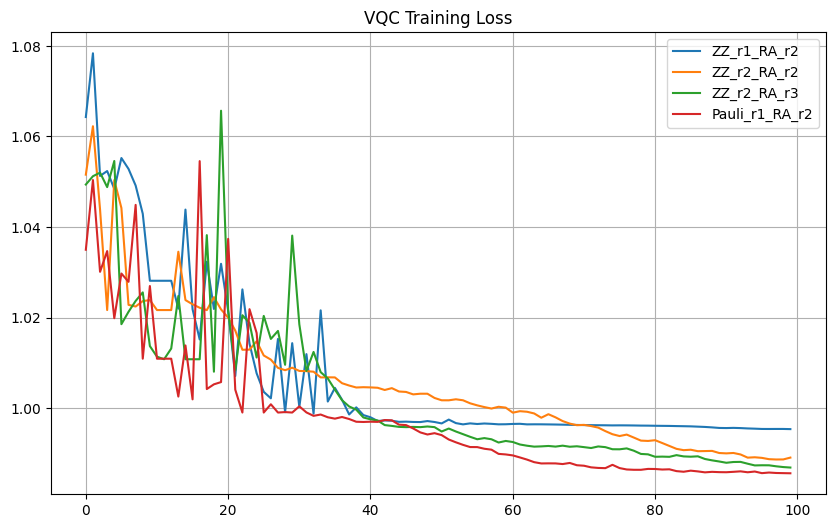

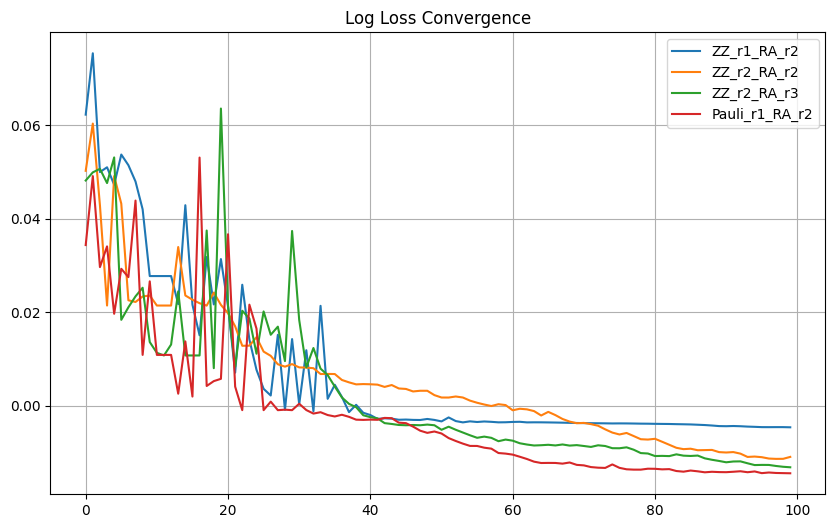

In [ ]:
plt.figure(figsize=(10,6))
for name, losses in loss_histories.items():
    plt.plot(losses, label=name)
plt.title("VQC Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
for name, losses in loss_histories.items():
    plt.plot(np.log(losses), label=name)
plt.title("Log Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()

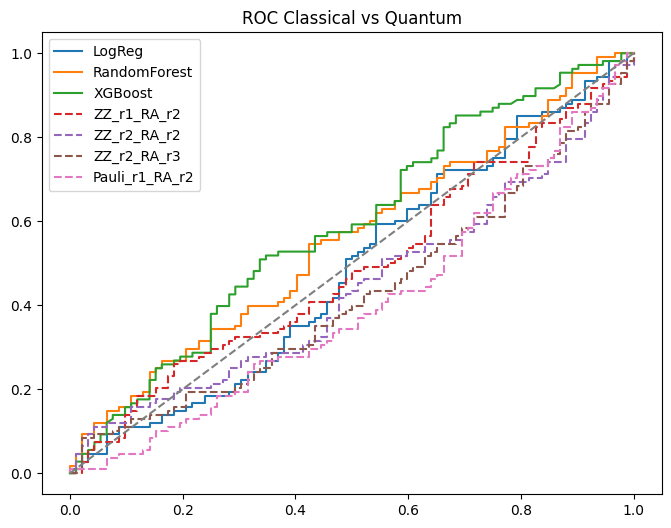

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

for name, model in vqc_models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, linestyle="--", label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Classical vs Quantum")
plt.show()

In [ ]:
print("Stability check:\n")

for name, (fmap, ansatz) in configs.items():
    scores = []
    for seed in range(5):
        np.random.seed(seed)

        vqc_tmp = VQC(
            feature_map=fmap,
            ansatz=ansatz,
            optimizer=COBYLA(maxiter=50)
        )

        vqc_tmp.fit(X_train, y_train)

        probs = vqc_tmp.predict_proba(X_test)[:,1]
        scores.append(roc_auc_score(y_test, probs))

    print(name,
          "Mean:", round(np.mean(scores),4),
          "Std:", round(np.std(scores),4))

Stability check:



ZZ_r1_RA_r2 Mean: 0.4337 Std: 0.0134


ZZ_r2_RA_r2 Mean: 0.4601 Std: 0.0142


ZZ_r2_RA_r3 Mean: 0.5013 Std: 0.0296


Pauli_r1_RA_r2 Mean: 0.461 Std: 0.0402


In [ ]:
meta_X_train = np.column_stack([
    models["RandomForest"].predict_proba(X_train)[:,1],
    vqc_models["ZZ_r2_RA_r3"].predict_proba(X_train)[:,1]
])

meta_X_test = np.column_stack([
    models["RandomForest"].predict_proba(X_test)[:,1],
    vqc_models["ZZ_r2_RA_r3"].predict_proba(X_test)[:,1]
])

meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_train)

meta_probs = meta_model.predict_proba(meta_X_test)[:,1]
meta_roc = roc_auc_score(y_test, meta_probs)

print("Stacking ROC:", round(meta_roc,4))

results.append(["Stacking_RF_VQC", "-", "-", meta_roc, "Hybrid", 2])

results_df = pd.DataFrame(results,
                          columns=["Model","Train Acc","Test Acc","ROC-AUC","Type","Parameters"])

Stacking ROC: 0.5401


In [ ]:
results_df = results_df.drop_duplicates(subset=["Model"], keep="first").reset_index(drop=True)


print("Final Results:\n")
print(results_df)

Final Results:

             Model Train Acc Test Acc   ROC-AUC       Type Parameters
0           LogReg  0.545797     0.43  0.484300  Classical          -
1     RandomForest  0.737767     0.51  0.554046  Classical          -
2          XGBoost       1.0    0.555  0.588215  Classical          -
3      ZZ_r1_RA_r2  0.548306     0.48  0.487721    Quantum         12
4      ZZ_r2_RA_r2  0.568381    0.445  0.440016    Quantum         12
5      ZZ_r2_RA_r3    0.5734    0.445  0.424416    Quantum         16
6   Pauli_r1_RA_r2  0.563363     0.43  0.402375    Quantum         12
7  Stacking_RF_VQC         -        -  0.540056     Hybrid          2


In [ ]:
f1_scores = []

for name, model in models.items():
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

for name, model in vqc_models.items():
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

meta_preds = meta_model.predict(meta_X_test)
f1_scores.append(f1_score(y_test, meta_preds))

results_df["F1"] = f1_scores

print(results_df)

             Model Train Acc Test Acc   ROC-AUC       Type Parameters  \
0           LogReg  0.545797     0.43  0.484300  Classical          -   
1     RandomForest  0.737767     0.51  0.554046  Classical          -   
2          XGBoost       1.0    0.555  0.588215  Classical          -   
3      ZZ_r1_RA_r2  0.548306     0.48  0.487721    Quantum         12   
4      ZZ_r2_RA_r2  0.568381    0.445  0.440016    Quantum         12   
5      ZZ_r2_RA_r3    0.5734    0.445  0.424416    Quantum         16   
6   Pauli_r1_RA_r2  0.563363     0.43  0.402375    Quantum         12   
7  Stacking_RF_VQC         -        -  0.540056     Hybrid          2   

         F1  
0  0.269231  
1  0.319444  
2  0.502793  
3  0.500000  
4  0.424870  
5  0.488479  
6  0.495575  
7  0.237037  


In [ ]:
lin_model = LogisticRegression()
lin_model.fit(X_train, y_train)

train_sep = lin_model.score(X_train, y_train)
test_sep = lin_model.score(X_test, y_test)

print("Theoretical linear separability:")
print("Train separability:", round(train_sep,4))
print("Test separability:", round(test_sep,4))

Theoretical linear separability:
Train separability: 0.5458
Test separability: 0.43


<Figure size 640x480 with 0 Axes>

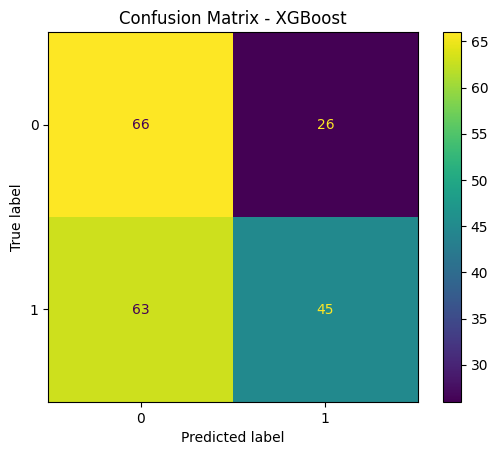

<Figure size 640x480 with 0 Axes>

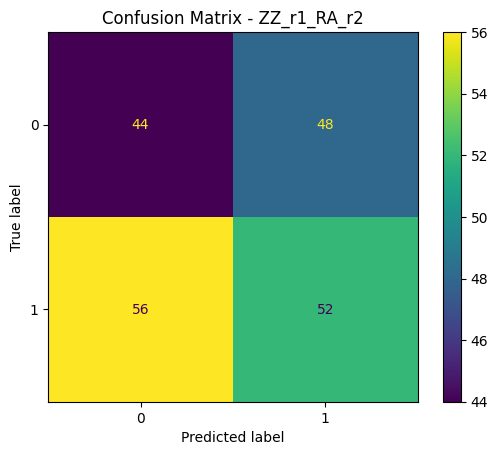

In [ ]:
best_classical = max(models.items(),
                     key=lambda x: roc_auc_score(y_test, x[1].predict_proba(X_test)[:,1]))

best_quantum = max(vqc_models.items(),
                   key=lambda x: roc_auc_score(y_test, x[1].predict_proba(X_test)[:,1]))

plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_classical[1].predict(X_test)
)
plt.title(f"Confusion Matrix - {best_classical[0]}")
plt.show()

plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_quantum[1].predict(X_test)
)
plt.title(f"Confusion Matrix - {best_quantum[0]}")
plt.show()

Stacking model coefficients:
  RandomForest weight: 9.429
  VQC weight: 1.678
  Intercept: -5.733


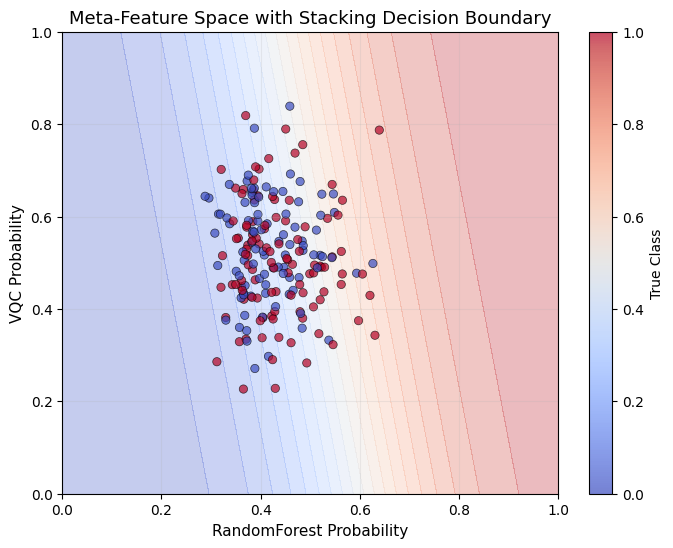

In [ ]:
plt.figure(figsize=(8,6))

xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = meta_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.3)

scatter = plt.scatter(meta_X_test[:,0], meta_X_test[:,1],
                      c=y_test, cmap="coolwarm",
                      edgecolors='black', linewidth=0.5, alpha=0.7)

plt.colorbar(scatter, label="True Class")
plt.xlabel("RandomForest Probability", fontsize=11)
plt.ylabel("VQC Probability", fontsize=11)
plt.title("Meta-Feature Space with Stacking Decision Boundary", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)

print(f"Stacking model coefficients:")
print(f"  RandomForest weight: {meta_model.coef_[0][0]:.3f}")
print(f"  VQC weight: {meta_model.coef_[0][1]:.3f}")
print(f"  Intercept: {meta_model.intercept_[0]:.3f}")
plt.show()

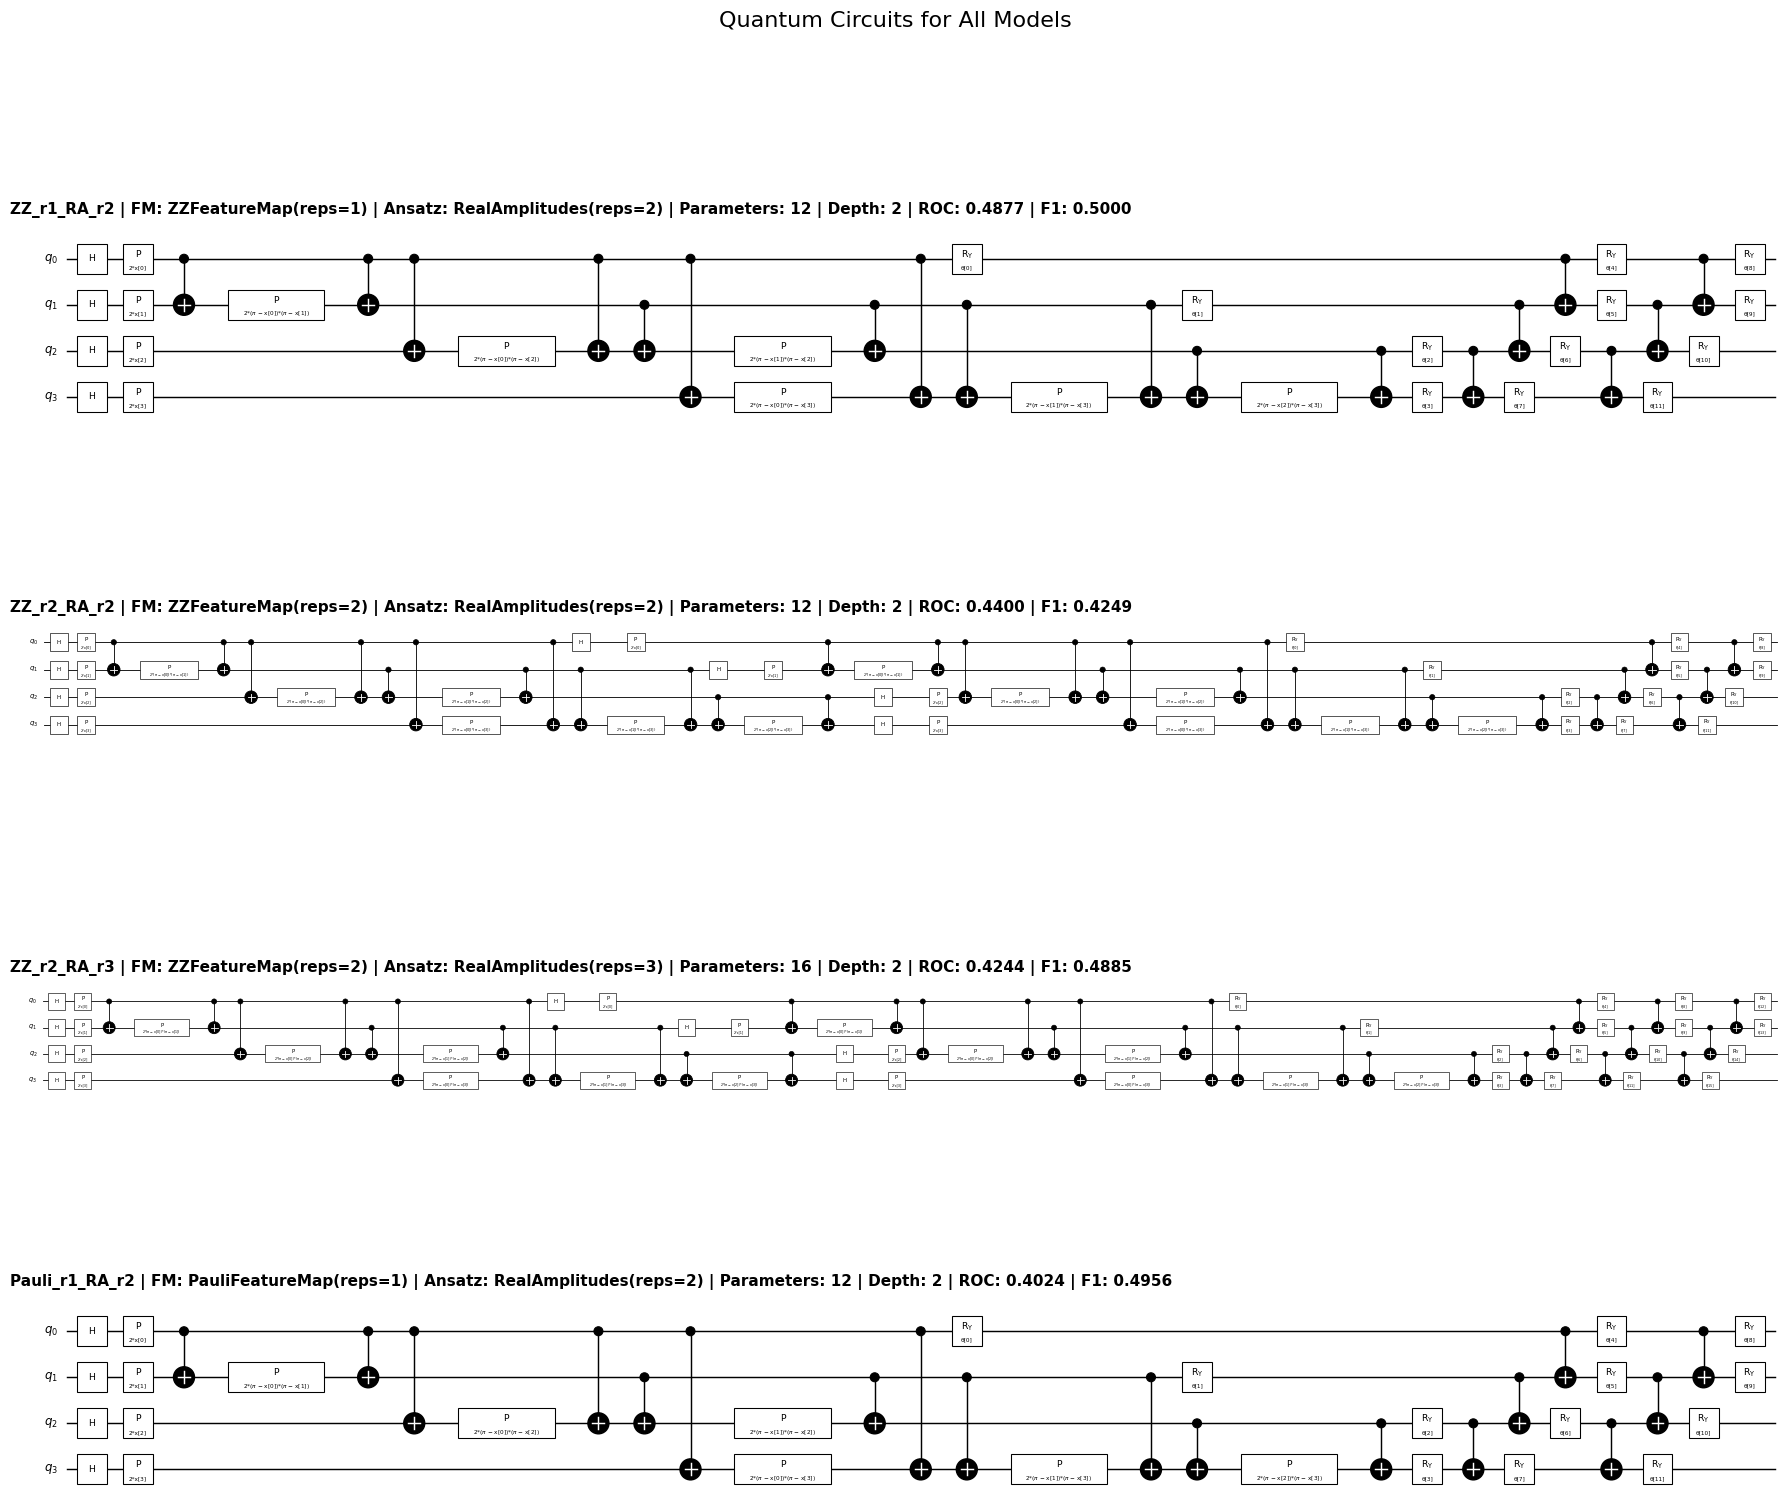

In [ ]:
quantum_models = list(configs.items())

fig, axes = plt.subplots(len(quantum_models), 1, figsize=(18, 4*len(quantum_models)))

if len(quantum_models) == 1:
    axes = [axes]

for idx, (name, (fmap, ansatz)) in enumerate(quantum_models):
    full_circuit = fmap.compose(ansatz)

    ax = axes[idx]
    circuit_drawer(full_circuit.decompose(), output='mpl', style={'name': 'bw'},
                   scale=0.6, ax=ax, plot_barriers=False, fold=120)

    roc_val = roc_scores.get(name, 0)
    f1_val = results_df[results_df["Model"] == name]["F1"].values[0] if name in results_df["Model"].values else 0

    ax.set_title(f"{name} | FM: {type(fmap).__name__}(reps={fmap.reps}) | "
                 f"Ansatz: {type(ansatz).__name__}(reps={ansatz.reps}) | "
                 f"Parameters: {ansatz.num_parameters} | Depth: {full_circuit.depth()} | "
                 f"ROC: {roc_val:.4f} | F1: {f1_val:.4f}",
                 fontsize=11, fontweight='bold', loc='left')

plt.suptitle("Quantum Circuits for All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

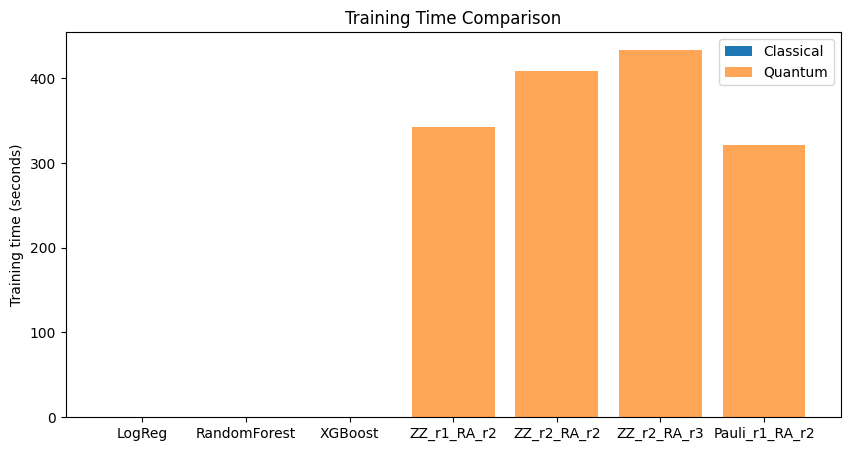

In [ ]:
classical_times = []
quantum_times = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    classical_times.append(time.time() - start)

for name in vqc_models.keys():
    quantum_times.append(train_times[name])

labels_classical = list(models.keys())
labels_quantum = list(vqc_models.keys())

plt.figure(figsize=(10,5))

plt.bar(labels_classical, classical_times, label="Classical")
plt.bar(labels_quantum, quantum_times, alpha=0.7, label="Quantum")

plt.ylabel("Training time (seconds)")
plt.title("Training Time Comparison")
plt.legend()
plt.show()

In [ ]:
def measure_inference(model, X, n_runs=100):

    start = time.time()

    for _ in range(n_runs):
        model.predict(X)

    return (time.time() - start) / n_runs


print("Inference Time (seconds per prediction batch):\n")

for name, model in models.items():
    t = measure_inference(model, X_test)
    print(name, round(t,6))

for name, model in vqc_models.items():
    t = measure_inference(model, X_test)
    print(name, round(t,6))


Inference Time (seconds per prediction batch):

LogReg 0.000207
RandomForest 0.022167
XGBoost 0.006035
ZZ_r1_RA_r2 0.810278
ZZ_r2_RA_r2 1.033982
ZZ_r2_RA_r3 1.088561
Pauli_r1_RA_r2 0.816556


In [25]:
print("Model complexity:\n")

for name, model in models.items():

    if hasattr(model, "coef_"):
        params = model.coef_.size
    elif hasattr(model, "feature_importances_"):
        params = len(model.feature_importances_)
    else:
        params = "unknown"

    print(name, "parameters:", params)

for name, (fmap, ansatz) in configs.items():
    print(name, "quantum parameters:", ansatz.num_parameters)


Model complexity:

LogReg parameters: 4
RandomForest parameters: 4
XGBoost parameters: 4
ZZ_r1_RA_r2 quantum parameters: 12
ZZ_r2_RA_r2 quantum parameters: 12
ZZ_r2_RA_r3 quantum parameters: 16
Pauli_r1_RA_r2 quantum parameters: 12


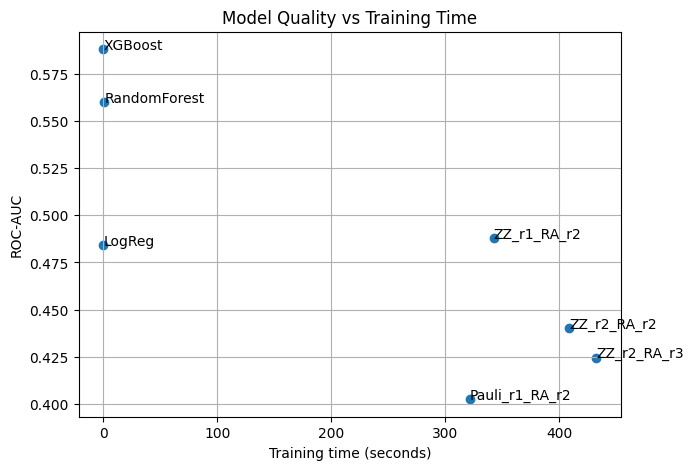

In [26]:
roc_vals = []
time_vals = []
labels = []

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    roc_vals.append(roc)
    labels.append(name)

for name in vqc_models.keys():

    roc_vals.append(roc_scores[name])
    time_vals.append(train_times[name])
    labels.append(name)

time_vals = classical_times + quantum_times

plt.figure(figsize=(7,5))

plt.scatter(time_vals, roc_vals)

for i, label in enumerate(labels):
    plt.text(time_vals[i], roc_vals[i], label)

plt.xlabel("Training time (seconds)")
plt.ylabel("ROC-AUC")
plt.title("Model Quality vs Training Time")
plt.grid(True)

plt.show()